In [1]:
library(limma)

In [2]:
# Definir las rutas 
path_monocyte <- "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte"
path_decidual  <- "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual"

In [3]:
# Opción A: Buscar archivos que terminen en .txt (Lo más probable)
files_monocyte <- list.files(path = path_monocyte,
                             pattern = "\\.txt$", 
                             full.names = TRUE)

files_decidual <- list.files(path = path_decidual,
                             pattern = "\\.txt$", 
                             full.names = TRUE)

# Opción B: Buscar cualquier cosa que empiece con "GSM" (Más permisivo)
# files_monocyte <- list.files(path = path_monocyte, pattern = "^GSM", full.names = TRUE)

In [4]:
# Combinar ambas listas de archivos
all_files <- c(files_monocyte, files_decidual)
print(all_files)
print(paste("Archivos encontrados:", length(all_files)))

[1] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758935.txt"
[2] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758937.txt"
[3] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758938.txt"
[4] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758936.txt"
[5] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758939.txt"
[6] "C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758946.txt"
[1] "Archivos encontrados: 6"


In [5]:
# Leemos los archivos. 
# source="agilent" le dice a R qué columnas buscar.
# green.only=TRUE es porque casi seguro son de un solo color (Cy3).
raw_data <- read.maimages(all_files, source="agilent", green.only=TRUE)

# Fijate que haya cargado bien
print(dim(raw_data))

Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758935.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758937.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawMonocyte/GSM758938.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758936.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758939.txt 
Read C:/Users/Fran/Documents/Doctorado/Dani/GSE30595/RawDecidual/GSM758946.txt 
[1] 15744     6


In [6]:
# 1. Definimos los IDs de cada grupo (según tu lista definitiva)
ids_monocyte <- c("GSM758936", "GSM758939", "GSM758946")
ids_decidual  <- c("GSM758935", "GSM758937", "GSM758938")


# 2. Función para detectar el grupo según el nombre del archivo
asignar_grupo <- function(ruta_completa) {
  archivo <- basename(ruta_completa)       # Se queda solo con el nombre "GSM...txt"
  nombre_limpio <- sub("\\.txt$", "", archivo) # Le saca el .txt

  if (nombre_limpio %in% ids_monocyte) return("Monocyte")
  if (nombre_limpio %in% ids_decidual)  return("Decidual")

  return("Desconocido")
}

# 3. Creamos la tabla de targets y la metemos dentro del objeto raw_data
mis_grupos <- sapply(all_files, asignar_grupo)
raw_data$targets <- data.frame(FileName = basename(all_files), Group = mis_grupos)

# Chequeo rápido: ¿Están bien contados?
table(raw_data$targets$Group)


Decidual Monocyte 
       3        3 

In [7]:
# Paso 3: Normalización para Single-Channel (Agilent)

# A. Corrección de fondo (Background Correction)
# offset=16 o 50 ayuda a evitar logaritmos de cero más adelante.
data_bkg <- backgroundCorrect(raw_data, method="normexp", offset=50)

# B. Normalización entre arrays (Quantile)
# Esto alinea las distribuciones de todas tus muestras
data_norm <- normalizeBetweenArrays(data_bkg, method="quantile")

# Chequeo:
# Si mirás las dimensiones, deben ser las mismas (aprox 40k genes x 22 muestras)
dim(data_norm)

Array 1 corrected
Array 2 corrected
Array 3 corrected
Array 4 corrected
Array 5 corrected
Array 6 corrected


[1] 15744     6

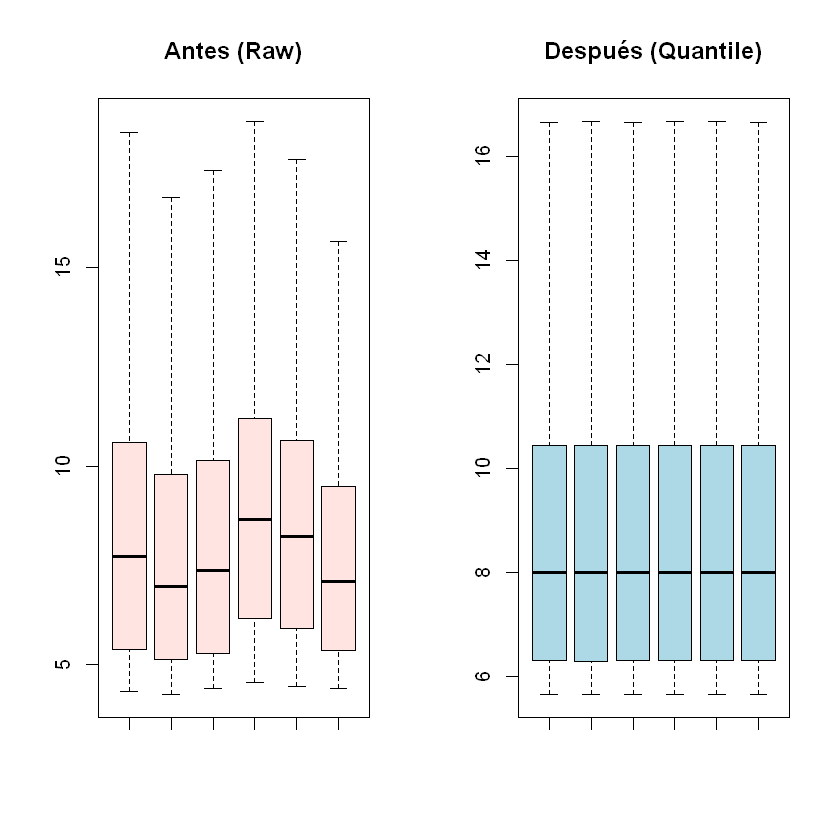

In [8]:
# Comparación visual
par(mfrow=c(1,2)) # Dividir pantalla en 2

# 1. Antes (Usa raw_data$E porque es single channel)
# log2 transforma los datos para que se vean mejor en el gráfico
boxplot(log2(raw_data$E), main="Antes (Raw)", names=FALSE, col="mistyrose", outline=FALSE)

# 2. Después (data_norm ya viene en escala logarítmica usualmente tras normalizeBetweenArrays si son 1-color, 
# pero por las dudas chequeamos sus valores. Para Agilent suele devolver log-expression values).
boxplot(data_norm$E, main="Después (Quantile)", names=FALSE, col="lightblue", outline=FALSE)

In [9]:
# Verificamos qué tipo de sondas hay (0 son genes, 1/-1 son controles técnicos)
table(data_norm$genes$ControlType)

# Nos quedamos SOLO con las que son genes (ControlType == 0)
# La función subset de limma sirve para filtrar filas manteniendo la estructura
data_clean <- data_norm[data_norm$genes$ControlType == 0, ]

# Chequeamos cuántos genes nos quedaron (deberían ser unos 30.000 - 40.000 aprox)
dim(data_clean)


   -1     0     1 
   77 15208   459 

[1] 15208     6

In [10]:
# Función rápida para asignar Donante según el número de GSM
asignar_donante <- function(nombre_archivo) {
  # Extraemos el numero del nombre del archivo
  id <- sub("GSM", "", sub("\\.txt", "", basename(nombre_archivo)))
  
  # Mapeo según la investigación que hicimos antes:
  # M#20: 65(C), 66(E), 67(P), 02(Combo)
  if(id %in% c("758935","758936")) return("Donante37")
  
  # M#21: 69(C), 70(E), 71(P), 74(Combo)
  if(id %in% c("758937","758946")) return("Donante38")
  
  # M#25: 04(C), 05(E), 06(P), 09(Combo)
  if(id %in% c("758938","758939")) return("Donante39")

  return("Otros") # Para los huerfanos del M23 si los cargaste
}

# Creamos la columna Donante en los targets
data_clean$targets$Donante <- sapply(data_clean$targets$FileName, asignar_donante)

# Miramos la tabla cruzada para ver que cada donante tenga sus tratamientos
table(data_clean$targets$Donante, data_clean$targets$Group)

           
            Decidual Monocyte
  Donante37        1        1
  Donante38        1        1
  Donante39        1        1

In [11]:
# Definimos los factores
Grupo   <- factor(data_clean$targets$Group)
Donante <- factor(data_clean$targets$Donante)

# Creamos la matriz de diseño
# "~ 0 + Grupo + Donante" significa:
# "Explicame la expresión génica basándote en el Tratamiento, pero ajustando por el Donante"
design <- model.matrix(~ 0 + Grupo + Donante)

# Limpiamos los nombres de las columnas para que sea fácil leerlos después
colnames(design) <- gsub("Grupo", "", colnames(design))

# Revisamos cómo quedó la matriz (solo las primeras filas)
head(design)

,Decidual,Monocyte,DonanteDonante38,DonanteDonante39
1,1,0,0,0
2,1,0,1,0
3,1,0,0,1
4,0,1,0,0
5,0,1,0,1
6,0,1,1,0


In [12]:
# 1. Filtramos: Nos quedamos solo con los que NO son "Otros"
keep <- data_clean$targets$Donante != "Otros"
data_final <- data_clean[, keep]

# 2. Re-factorizamos para borrar los niveles vacíos (fantasmas)
data_final$targets$Group   <- factor(data_final$targets$Group)
data_final$targets$Donante <- factor(data_final$targets$Donante)

# 3. Ponemos al "Control" como la REFERENCIA (el nivel basal)
# Esto es clave: le dice a R que todo se compara CONTRA el Control.
data_final$targets$Group <- relevel(data_final$targets$Group, ref="Monocyte")

# Chequeo final (Ahora "Otros" debería haber desaparecido)
table(data_final$targets$Donante, data_final$targets$Group)

           
            Monocyte Decidual
  Donante37        1        1
  Donante38        1        1
  Donante39        1        1

In [21]:
# --- 1. MODELADO (Tus pasos A, B, C) ---

# A. Matriz de diseño
design <- model.matrix(~ Donante + Group, data = data_final$targets)

# B. Ajustamos el modelo lineal
fit <- lmFit(data_final, design)

# C. Calculamos la estadística Bayesiana
fit <- eBayes(fit)

# D. Chequeamos nombres (debería aparecer "GroupDecidual")
print(colnames(design))

[1] "(Intercept)"      "DonanteDonante38" "DonanteDonante39" "GroupDecidual"   


In [22]:
# --- 2. EXTRACCIÓN Y FILTRADO ---

# Paso 1: Obtener la tabla cruda completa
# coef="GroupDecidual" asume que "Monocyte" es la referencia (según tu relevel anterior)
top_table_full <- topTable(fit, coef="GroupDecidual", number=Inf, sort.by="P")

# Paso 2: Filtrar ordenadamente
# Criterios: FDR (adj.P.Val) < 0.05  Y  Cambio Biológico (LogFC) > 1
res_significativos <- top_table_full %>%
  filter(adj.P.Val < 0.05 & abs(logFC) > 1) %>%
  dplyr::select(logFC, AveExpr, P.Value, adj.P.Val) %>% # Usamos dplyr:: para evitar el error de antes
  arrange(desc(abs(logFC))) # Ordenamos por magnitud del cambio

In [23]:
# --- 3. RESULTADOS ---

# Ver cuántas sondas pasaron el filtro
print(paste("Cantidad de sondas significativas:", nrow(res_significativos)))

# Ver las top 10 (las IDs serán las sondas originales, ej: NM_xxxx o A_23_P...)
head(res_significativos, 10)

# Ver desglose: Cuántos subieron (TRUE) vs bajaron (FALSE)
table(res_significativos$logFC > 0)

[1] "Cantidad de sondas significativas: 3632"


,logFC,AveExpr,P.Value,adj.P.Val
,<dbl>,<dbl>,<dbl>,<dbl>
9545,-10.545459,11.37013,3.315264e-07,0.0005826522
8580,-10.413917,11.40810,1.562227e-07,0.0005826522
5629,-10.396805,11.68704,7.139635e-07,0.0005826522
13466,-10.331310,11.21874,3.002299e-07,0.0005826522
5806,-10.264867,11.64533,2.225043e-06,0.0006191386
1944,-10.242342,11.69206,1.081918e-06,0.0005826522
9094,-10.162275,11.60264,1.930633e-06,0.0006191386
13677,-10.127533,11.20962,9.738529e-07,0.0005826522
1727,-10.000156,11.68685,1.050659e-06,0.0005826522



FALSE  TRUE 
 1654  1978 

## Traducir a symbol

In [24]:
library(org.Hs.eg.db)
library(AnnotationDbi)

# Traducimos de REFSEQ (tus códigos NM_...) a SYMBOL (nombres de genes)
# Usamos 'SystematicName' porque ahí están los códigos en tu data
fit$genes$Symbol <- mapIds(org.Hs.eg.db,
                           keys = fit$genes$SystematicName, 
                           column = "SYMBOL",
                           keytype = "REFSEQ",
                           multiVals = "first")

# Chequeamos que aparezca la columna Symbol
head(fit$genes)

'select()' returned 1:1 mapping between keys and columns



,Row,Col,ControlType,ProbeName,SystematicName,Symbol
,<int>,<int>,<int>,<chr>,<chr>,<chr>
4,1,4,0,A_23_P335388,NM_173625,C17orf78
5,1,5,0,A_23_P887,NM_014002,IKBKE
6,1,6,0,A_23_P15692,NM_017986,SLC52A1
7,1,7,0,A_32_P165611,NM_015254,KIF13B
8,1,8,0,A_33_P3390172,NM_001145271,ADAMDEC1
9,1,9,0,A_23_P329112,NM_000215,JAK3


In [ ]:
library(org.Hs.eg.db)
library(AnnotationDbi)
library(dplyr)

# --- PASO 1: Mapear IDs a Symbols dentro del objeto 'fit' ---
# Usamos 'SystematicName' (tus códigos NM_...) para buscar el SYMBOL
# Si mapIds tira warning de "1:many mapping", no te preocupes, 'multiVals="first"' lo resuelve.
fit$genes$Symbol <- mapIds(org.Hs.eg.db,
                           keys = fit$genes$SystematicName, 
                           column = "SYMBOL",
                           keytype = "REFSEQ",
                           multiVals = "first")

# --- PASO 2: Extraer la tabla nuevamente (ahora incluirá la columna Symbol) ---
# Al haber modificado fit$genes, topTable trae automáticamente la columna nueva.
tabla_cruda <- topTable(fit, coef="GroupDecidual", number=Inf, sort.by="P")

# --- PASO 3: Filtrar, Limpiar Duplicados y Ordenar ---
res_final_symbols <- tabla_cruda %>%
  # A. Eliminamos filas que no encontraron traducción a Symbol (NA)
  filter(!is.na(Symbol) & Symbol != "") %>%
  
  # B. Aplicamos tus filtros: FDR < 0.05 y LogFC > 1
  filter(adj.P.Val < 0.05 & abs(logFC) > 1) %>%
  
  # C. Colapsar duplicados: si un gen aparece varias veces, nos quedamos con el de menor P-Value
  group_by(Symbol) %>%
  slice_min(order_by = P.Value, n = 1) %>%
  ungroup() %>%
  
  # D. Ordenar por magnitud de cambio (LogFC)
  arrange(desc(abs(logFC))) %>%
  
  # E. Seleccionar columnas finales (Usamos dplyr::select para evitar el error)
  dplyr::select(Symbol, logFC, AveExpr, P.Value, adj.P.Val)

# --- RESULTADO FINAL ---
print(paste("Genes únicos significativos:", nrow(res_final_symbols)))

# Ver los primeros 10
head(res_final_symbols, 10)

# (Opcional) Guardar
 write.csv(res_final_symbols, "Resultados_Finales_Symbols.csv", row.names=FALSE)

'select()' returned 1:1 mapping between keys and columns



[1] "Genes únicos significativos: 1212"


Symbol,logFC,AveExpr,P.Value,adj.P.Val
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
SELENOP,-10.413917,11.40810,1.562227e-07,0.0005826522
A2M,-10.396805,11.68704,7.139635e-07,0.0005826522
APOE,-9.768039,13.31313,9.452944e-06,0.0011144215
SPP1,-9.515605,10.73940,3.164257e-07,0.0005826522
SLCO2B1,-8.685647,10.33039,3.103992e-07,0.0005826522
RNASE1,-8.504439,13.58149,2.713941e-06,0.0006191386
APOC1,-8.309186,10.12124,5.252511e-06,0.0008589267
NUPR1,-7.792272,10.26662,1.987137e-05,0.0013612785
PLTP,-7.772451,11.24063,1.487815e-06,0.0006002660


In [27]:

# (Opcional) Guardar
 write.csv(res_final_symbols, "Resultados_Finales_Symbols.csv", row.names=FALSE)

# Para el gsea

In [28]:
# --- 1. Extraer TODOS los datos ---
# number=Inf trae todo.
# sort.by="P" nos ayuda preliminarmente para elegir la mejor sonda después.
tabla_completa_gsea <- topTable(fit, coef="GroupDecidual", number=Inf, sort.by="P")

# --- 2. Procesar para GSEA (Sin filtrar por significancia) ---
res_gsea <- tabla_completa_gsea %>%
  # A. Limpieza básica: Solo genes con Symbol real
  filter(!is.na(Symbol) & Symbol != "") %>%
  
  # B. Colapsar Duplicados:
  # Igual que antes, si hay varias sondas para el mismo gen, 
  # nos quedamos con la que tiene el P-Valor más bajo (la señal más clara).
  group_by(Symbol) %>%
  slice_min(order_by = P.Value, n = 1) %>%
  ungroup() %>%
  
  # C. AQUÍ ESTÁ LA DIFERENCIA: NO FILTRAMOS (LFC > 0 y Padj < 1)
  # Queremos todos los genes para el background del GSEA.
  
  # D. Ordenar para el ranking (Ranking Metric)
  # Ordenamos por estadístico t (descendente). 
  # Esto pone los genes más inducidos arriba y los más reprimidos abajo.
  arrange(desc(t)) %>%
  
  # E. Seleccionar columnas clave para GSEA
  # Agregamos la columna 't' que es la ideal para el archivo .rnk
  dplyr::select(Symbol, t, logFC, P.Value, adj.P.Val)

# --- 3. Revisión Final ---
print(paste("Total de genes listos para GSEA:", nrow(res_gsea)))

# Ver la cabecera (Genes inducidos)
head(res_gsea)

# Ver el final de la cola (Genes reprimidos)
tail(res_gsea)

# --- 4. Exportar para GSEA ---
# GSEA suele pedir un archivo .rnk de dos columnas: Symbol y métrica (t)
write.table(res_gsea[, c("Symbol", "t")], 
            file = "Decidual_vs_Monocyte_GSEA.rnk", 
            quote = FALSE, sep = "\t", row.names = FALSE, col.names = FALSE)

# O guardar la tabla completa por si la necesitas para otra cosa
write.csv(res_gsea, "Tabla_Completa_GSEA.csv", row.names = FALSE)

[1] "Total de genes listos para GSEA: 5877"


Symbol,t,logFC,P.Value,adj.P.Val
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MEGF9,41.49286,4.216560,2.612209e-06,0.0006191386
C11orf21,38.95612,4.017126,3.339720e-06,0.0006922198
CD244,33.98441,3.529069,5.682480e-06,0.0008673851
VCAN,33.32466,4.073989,6.132926e-06,0.0008819515
S100A9,28.24614,3.961681,1.166590e-05,0.0011590659
CSF3R,28.07007,2.928105,1.195288e-05,0.0011652524


Symbol,t,logFC,P.Value,adj.P.Val
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
IGF1,-56.55646,-5.909023,7.813413e-07,0.0005826522
A2M,-57.87997,-10.396805,7.139635e-07,0.0005826522
TREM2,-59.83473,-6.192967,6.272442e-07,0.0005826522
SPP1,-71.31180,-9.515605,3.164257e-07,0.0005826522
SLCO2B1,-71.66429,-8.685647,3.103992e-07,0.0005826522
SELENOP,-85.45797,-10.413917,1.562227e-07,0.0005826522
